<a href="https://colab.research.google.com/github/ShashankSatishkumar/Lasers/blob/main/BGSfordiffpumpprof.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<>:48: SyntaxWarning: invalid escape sequence '\D'
<>:48: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_1676/1766619299.py:48: SyntaxWarning: invalid escape sequence '\D'
  plt.xlabel('Frequency Detuning from Resonance, $\Delta\\nu$ (MHz)', fontsize=12)


Monochromatic FWHM:  29.73 MHz
Lorentzian-Pumped FWHM: 79.58 MHz
Gaussian-Pumped FWHM:   67.57 MHz


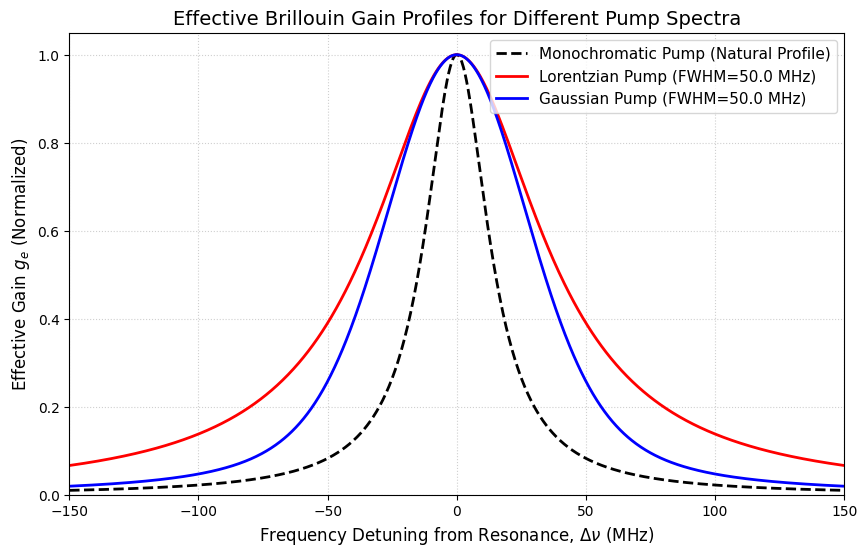

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import wofz
def fwhm_find(x,y):
  ymx=np.max(y)
  ymxh=ymx/2.0
  ah=np.where(y>=ymxh)[0]
  fwhm=x[ah[-1]]-x[ah[0]]
  return fwhm
def monoprof(dif,gB, Gamma_B):
  return gB*(Gamma_B/2)**2/((Gamma_B/2)**2+dif**2)
def lor_prof(dif,gB,Gamma_B,pump_w):
  G_eff= (Gamma_B+pump_w)/2
  r = np.pi * (pump_w / 2)
  num=gB*(Gamma_B/2)*G_eff*r
  den=G_eff**2+dif**2
  return num/den
def gaus_prof(dif,gB, Gamma_B,pump_w):
  s_p=pump_w/(2*np.sqrt(2*np.log(2)))
  x = dif/ (np.sqrt(2) * s_p)
  y = Gamma_B / (2 * np.sqrt(2) * s_p)
  z = x + 1j * y
  profile = np.real(wofz(z))
  scaling = gB * np.sqrt(np.pi / 2) * (Gamma_B / (2 * s_p))
  r = np.sqrt(2 * np.pi) * s_p
  return scaling * profile*r
gB_peak=1.0
Gamma_B=30.0
pump_w=50.0
dif=np.linspace(-150,150,1000)
mono=monoprof(dif,gB_peak,Gamma_B)
lor=lor_prof(dif,gB_peak,Gamma_B,pump_w)
gaus=gaus_prof(dif,gB_peak,Gamma_B,pump_w)
mono=mono/np.max(mono)
lor=lor/np.max(lor)
gaus=gaus/np.max(gaus)
gaus_fwhm=fwhm_find(dif,gaus)
lor_fwhm=fwhm_find(dif,lor)
mono_fwhm=fwhm_find(dif,mono)
print(f"Monochromatic FWHM:  {mono_fwhm:.2f} MHz")
print(f"Lorentzian-Pumped FWHM: {lor_fwhm:.2f} MHz")
print(f"Gaussian-Pumped FWHM:   {gaus_fwhm:.2f} MHz")
plt.figure(figsize=(10, 6))
plt.plot(dif, mono, 'k--', label='Monochromatic Pump (Natural Profile)', linewidth=2)
plt.plot(dif, lor, 'r-', label=f'Lorentzian Pump (FWHM={pump_w} MHz)', linewidth=2)
plt.plot(dif, gaus, 'b-', label=f'Gaussian Pump (FWHM={pump_w} MHz)', linewidth=2)
plt.title('Effective Brillouin Gain Profiles for Different Pump Spectra', fontsize=14)
plt.xlabel('Frequency Detuning from Resonance, $\Delta\\nu$ (MHz)', fontsize=12)
plt.ylabel('Effective Gain $g_e$ (Normalized)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11)
plt.xlim([-150, 150])
plt.ylim([0, 1.05])
plt.show()
